In [340]:
from astropy.table import Table
from astropy.io import fits
import numpy as np
import pylab as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as fitter
import read_mist_models
%matplotlib inline

In [250]:
S1 = read_mist_models.EEP('0010000M.track.eep')
S2 = read_mist_models.EEP('0060000M.track.eep')
S3 = read_mist_models.EEP('0110000M.track.eep')
S4 = read_mist_models.EEP('0160000M.track.eep')
S5 = read_mist_models.EEP('0210000M.track.eep')
S6 = read_mist_models.EEP('0260000M.track.eep')
S7 = read_mist_models.EEP('0310000M.track.eep')
S8 = read_mist_models.EEP('0360000M.track.eep')
S9 = read_mist_models.EEP('0410000M.track.eep')
S10 = read_mist_models.EEP('0460000M.track.eep')
S11 = read_mist_models.EEP('0510000M.track.eep')

Reading in: 0010000M.track.eep
Reading in: 0060000M.track.eep
Reading in: 0110000M.track.eep
Reading in: 0160000M.track.eep
Reading in: 0210000M.track.eep
Reading in: 0260000M.track.eep
Reading in: 0310000M.track.eep
Reading in: 0360000M.track.eep
Reading in: 0410000M.track.eep
Reading in: 0460000M.track.eep
Reading in: 0510000M.track.eep


In [252]:
print ('version: ', S1.version)
print ('abundances: ', S1.abun)
print ('rotation: ', S1.rot)
print ('initial mass: ', S1.minit)
print ('available columns: ', S1.hdr_list)

print ('version: ', S2.version)
print ('abundances: ', S2.abun)
print ('rotation: ', S2.rot)
print ('initial mass: ', S2.minit)
print ('available columns: ', S2.hdr_list)

print ('version: ', S3.version)
print ('abundances: ', S3.abun)
print ('rotation: ', S3.rot)
print ('initial mass: ', S3.minit)
print ('available columns: ', S3.hdr_list)

print ('version: ', S4.version)
print ('abundances: ', S4.abun)
print ('rotation: ', S4.rot)
print ('initial mass: ', S4.minit)
print ('available columns: ', S4.hdr_list)

print ('version: ', S5.version)
print ('abundances: ', S5.abun)
print ('rotation: ', S5.rot)
print ('initial mass: ', S5.minit)
print ('available columns: ', S5.hdr_list)

print ('version: ', S6.version)
print ('abundances: ', S6.abun)
print ('rotation: ', S6.rot)
print ('initial mass: ', S6.minit)
print ('available columns: ', S6.hdr_list)

print ('version: ', S7.version)
print ('abundances: ', S7.abun)
print ('rotation: ', S7.rot)
print ('initial mass: ', S7.minit)
print ('available columns: ', S7.hdr_list)

print ('version: ', S8.version)
print ('abundances: ', S8.abun)
print ('rotation: ', S8.rot)
print ('initial mass: ', S8.minit)
print ('available columns: ', S8.hdr_list)

print ('version: ', S9.version)
print ('abundances: ', S9.abun)
print ('rotation: ', S9.rot)
print ('initial mass: ', S9.minit)
print ('available columns: ', S9.hdr_list)

print ('version: ', S10.version)
print ('abundances: ', S10.abun)
print ('rotation: ', S10.rot)
print ('initial mass: ', S10.minit)
print ('available columns: ', S10.hdr_list)

print ('version: ', S11.version)
print ('abundances: ', S11.abun)
print ('rotation: ', S11.rot)
print ('initial mass: ', S11.minit)
print ('available columns: ', S11.hdr_list)

version:  {'MIST': '1.2', 'MESA': '7503'}
abundances:  {'Yinit': 0.2703, 'Zinit': 0.0142857, '[Fe/H]': 0.0, '[a/Fe]': 0.0}
rotation:  0.4
initial mass:  1.0
available columns:  ['star_age', 'star_mass', 'star_mdot', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'log_L', 'log_L_div_Ledd', 'log_LH', 'log_LHe', 'log_LZ', 'log_Teff', 'log_abs_Lgrav', 'log_R', 'log_g', 'log_surf_z', 'surf_avg_omega', 'surf_avg_v_rot', 'surf_num_c12_div_num_o16', 'v_wind_Km_per_s', 'surf_avg_omega_crit', 'surf_avg_omega_div_omega_crit', 'surf_avg_v_crit', 'surf_avg_v_div_v_crit', 'surf_avg_Lrad_div_Ledd', 'v_div_csound_surf', 'surface_h1', 'surface_he3', 'surface_he4', 'surface_li7', 'surface_be9', 'surface_b11', 'surface_c12', 'surface_c13', 'surface_n14', 'surface_o16', 'surface_f19', 'surface_ne20', 'surface_na23', 'surface_mg24', 'surface_si28', 'surface_s32', 'surface_ca40', 'surface_ti48', 'surface_fe56', 'log_center_T', 'log_center_Rho', 'center_degeneracy', 'center_omega', 'center_gamma', 'mass_conv_

In [308]:
Age = eep.eeps['star_age']
Mass = eep.eeps['star_mass']
Lum = eep.eeps['log_L']
Teff = eep.eeps['log_Teff']
Grav = eep.eeps['log_abs_Lgrav']
cent_temp = eep.eeps['log_center_T']
cent_dense = eep.eeps['log_center_Rho']
center_h = eep.eeps['center_h1']
center_he4 = eep.eeps['center_he4']
center_c12 = eep.eeps['center_c12']
Rad = eep.eeps['log_R']

Age1 = S1.eeps['star_age']
Mass1 = S1.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense1 = S1.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad1 = S1.eeps['log_R']

Age2 = S2.eeps['star_age']
Mass2 = S2.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense2 = S2.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad2 = S2.eeps['log_R']

Age3 = S3.eeps['star_age']
Mass3 = S3.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense3 = S3.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad3 = S3.eeps['log_R']

Age4 = S4.eeps['star_age']
Mass4 = S4.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense4 = S4.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad4 = S4.eeps['log_R']

Age5 = S5.eeps['star_age']
Mass5 = S5.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense5 = S5.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad5 = S5.eeps['log_R']

Age6 = S6.eeps['star_age']
Mass6 = S6.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense6 = S6.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad6 = S6.eeps['log_R']

Age7 = S7.eeps['star_age']
Mass7 = S7.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense7 = S7.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad7 = S7.eeps['log_R']

Age8 = S8.eeps['star_age']
Mass8 = S8.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense8 = S8.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad8 = S8.eeps['log_R']

Age9 = S9.eeps['star_age']
Mass9 = S9.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense9 = S9.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad9 = S9.eeps['log_R']

Age10 = S10.eeps['star_age']
Mass10 = S10.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense10 = S10.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad10 = S10.eeps['log_R']

Age11 = S11.eeps['star_age']
Mass11 = S11.eeps['star_mass']
Lum1 = S1.eeps['log_L']
Teff1 = S1.eeps['log_Teff']
Grav1 = S1.eeps['log_abs_Lgrav']
cent_temp1 = S1.eeps['log_center_T']
cent_dense11 = S11.eeps['log_center_Rho']
center1_h1 = S1.eeps['center_h1']
center1_he4 = S1.eeps['center_he4']
center1_c12 = S1.eeps['center_c12']
Rad11 = S11.eeps['log_R']

In [336]:
filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age1,
    'Star Mass (Msun)': Mass1,
    'Star Radius (Rsun)': Rad1,
    'Log Center Density (g/cm^3)': cent_dense1
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age2,
    'Star Mass (Msun)': Mass2,
    'Star Radius (Rsun)': Rad2,
    'Log Center Density (g/cm^3)': cent_dense2
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)
filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age3,
    'Star Mass (Msun)': Mass3,
    'Star Radius (Rsun)': Rad3,
    'Log Center Density (g/cm^3)': cent_dense3
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age4,
    'Star Mass (Msun)': Mass4,
    'Star Radius (Rsun)': Rad4,
    'Log Center Density (g/cm^3)': cent_dense4
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age5,
    'Star Mass (Msun)': Mass5,
    'Star Radius (Rsun)': Rad5,
    'Log Center Density (g/cm^3)': cent_dense5
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age6,
    'Star Mass (Msun)': Mass6,
    'Star Radius (Rsun)': Rad6,
    'Log Center Density (g/cm^3)': cent_dense6
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age7,
    'Star Mass (Msun)': Mass7,
    'Star Radius (Rsun)': Rad7,
    'Log Center Density (g/cm^3)': cent_dense7
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age8,
    'Star Mass (Msun)': Mass8,
    'Star Radius (Rsun)': Rad8,
    'Log Center Density (g/cm^3)': cent_dense8
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age9,
    'Star Mass (Msun)': Mass9,
    'Star Radius (Rsun)': Rad9,
    'Log Center Density (g/cm^3)': cent_dense9
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age10,
    'Star Mass (Msun)': Mass10,
    'Star Radius (Rsun)': Rad10,
    'Log Center Density (g/cm^3)': cent_dense10
})

print(filtered_data.head())

filtered_data.to_csv('filtered_star_data.csv', index=False)

filtered_data = pd.DataFrame({
    'Star Age (Gyr)': Age11,
    'Star Mass (Msun)': Mass11,
    'Star Radius (Rsun)': Rad11,
    'Log Center Density (g/cm^3)': cent_dense11
})

print(filtered_data.head())

   Star Age (Gyr)  Star Mass (Msun)  Star Radius (Rsun)  \
0     1766.367861               1.0            1.174089   
1     1860.694700               1.0            1.171605   
2     1960.105501               1.0            1.169027   
3     2064.861875               1.0            1.166353   
4     2175.209577               1.0            1.163583   

   Log Center Density (g/cm^3)  
0                    -2.500124  
1                    -2.493132  
2                    -2.485876  
3                    -2.478348  
4                    -2.470545  
   Star Age (Gyr)  Star Mass (Msun)  Star Radius (Rsun)  \
0      332.549539               6.0            1.922759   
1      347.760412               6.0            1.920756   
2      363.614659               6.0            1.918691   
3      380.162040               6.0            1.916572   
4      397.444972               6.0            1.914381   

   Log Center Density (g/cm^3)  
0                    -3.996071  
1                    -3.99

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence

<function matplotlib.pyplot.show(close=None, block=None)>

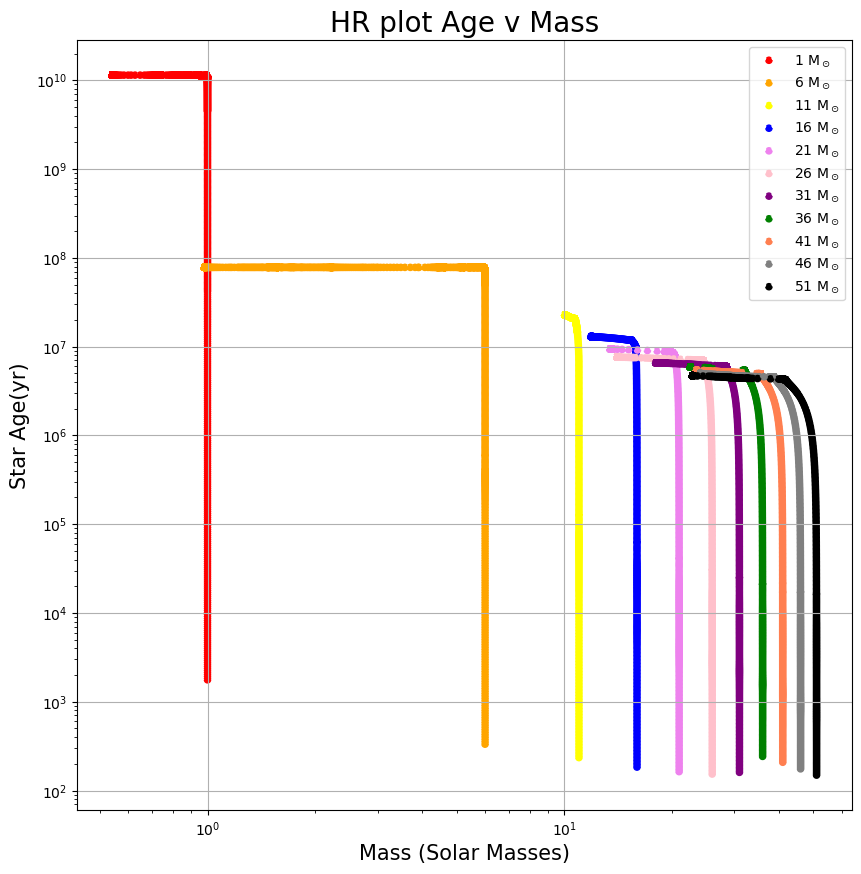

In [256]:
plt.figure(figsize=(10,10))

plt.scatter(Mass1, Age1, s=20, linestyle = 'dashed', color='red', label = '1 M$_\odot$' )
plt.scatter(Mass2, Age2, s=20, linestyle = 'dashed', color = 'orange', label = '6 M$_\odot$')
plt.scatter(Mass3, Age3, s=20, linestyle = 'dashed', color = 'yellow', label = '11 M$_\odot$')
plt.scatter(Mass4, Age4, s=20, linestyle = 'dashed', color = 'blue'  , label = '16 M$_\odot$')
plt.scatter(Mass5, Age5, s=20, linestyle = 'dashed', color = 'violet', label = '21 M$_\odot$')
plt.scatter(Mass6, Age6, s=20, linestyle = 'dashed', color = 'pink'  , label = '26 M$_\odot$')
plt.scatter(Mass7, Age7, s=20, linestyle = 'dashed', color = 'purple', label = '31 M$_\odot$')
plt.scatter(Mass8, Age8, s=20, linestyle = 'dashed', color = 'green' , label = '36 M$_\odot$')
plt.scatter(Mass9, Age9, s=20, linestyle = 'dashed', color = 'coral' , label = '41 M$_\odot$')
plt.scatter(Mass10, Age10, s=20, linestyle = 'dashed', color = 'grey', label = '46 M$_\odot$')
plt.scatter(Mass11, Age11, s=20, linestyle = 'dashed', color = 'black', label = '51 M$_\odot$')

plt.xscale('log')
plt.yscale('log')

plt.title('HR plot Age v Mass', fontsize=20)
plt.ylabel('Star Age(yr)', fontsize=15)
plt.xlabel('Mass (Solar Masses)', fontsize=15)
plt.grid(zorder=-1)
plt.legend(fontsize=10)
plt.show

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence

<function matplotlib.pyplot.show(close=None, block=None)>

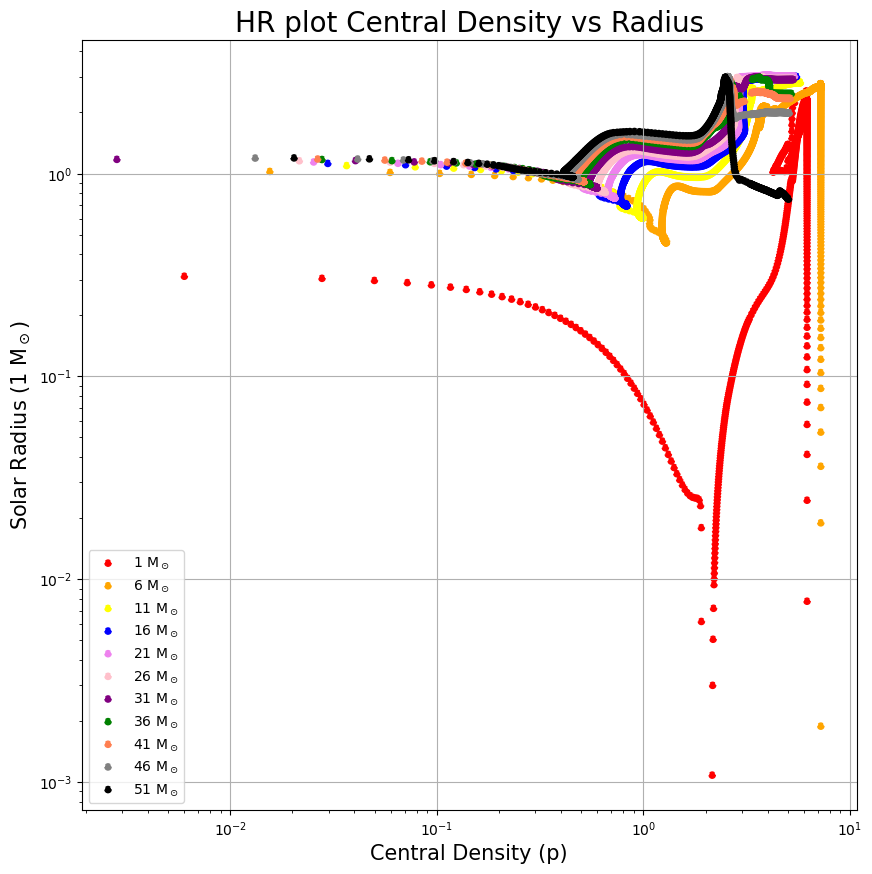

In [280]:
plt.figure(figsize=(10,10))

plt.scatter(cent_dense1, Rad1, s=20, linestyle = 'dashed', color='red', label = '1 M$_\odot$' )
plt.scatter(cent_dense2, Rad2, s=20, linestyle = 'dashed', color = 'orange', label = '6 M$_\odot$')
plt.scatter(cent_dense3, Rad3, s=20, linestyle = 'dashed', color = 'yellow', label = '11 M$_\odot$')
plt.scatter(cent_dense4, Rad4, s=20, linestyle = 'dashed', color = 'blue'  , label = '16 M$_\odot$')
plt.scatter(cent_dense5, Rad5, s=20, linestyle = 'dashed', color = 'violet', label = '21 M$_\odot$')
plt.scatter(cent_dense6, Rad6, s=20, linestyle = 'dashed', color = 'pink'  , label = '26 M$_\odot$')
plt.scatter(cent_dense7, Rad7, s=20, linestyle = 'dashed', color = 'purple', label = '31 M$_\odot$')
plt.scatter(cent_dense8, Rad8, s=20, linestyle = 'dashed', color = 'green' , label = '36 M$_\odot$')
plt.scatter(cent_dense9, Rad9, s=20, linestyle = 'dashed', color = 'coral' , label = '41 M$_\odot$')
plt.scatter(cent_dense10, Rad10, s=20, linestyle = 'dashed', color = 'grey', label = '46 M$_\odot$')
plt.scatter(cent_dense11, Rad11, s=20, linestyle = 'dashed', color = 'black', label = '51 M$_\odot$')

plt.xscale('log')
plt.yscale('log')

plt.title('HR plot Central Density vs Radius', fontsize=20)
plt.ylabel('Solar Radius (1 M$_\odot$)', fontsize=15)
plt.xlabel('Central Density (p)', fontsize=15)
plt.grid(zorder=-1)
plt.legend(fontsize=10)
plt.show

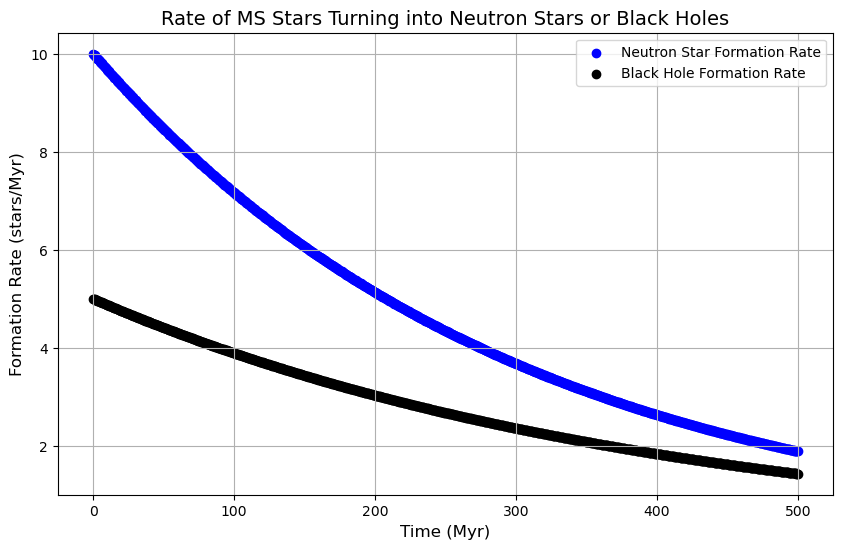

In [282]:
time = np.linspace(0, 500, 1000) 
rate_NS = 10 * np.exp(-time / 300)  
rate_BH = 5 * np.exp(-time / 400)

plt.figure(figsize=(10, 6))
plt.scatter(time, rate_NS, label='Neutron Star Formation Rate', color='blue')
plt.scatter(time, rate_BH, label='Black Hole Formation Rate', color='black')

plt.title('Rate of MS Stars Turning into Neutron Stars or Black Holes', fontsize=14)
plt.xlabel('Time (Myr)', fontsize=12)
plt.ylabel('Formation Rate (stars/Myr)', fontsize=12)
plt.legend()
plt.grid()
plt.show()

In [260]:
Mass1

array([0.99999993, 0.99999993, 0.99999993, ..., 0.53983176, 0.53983176,
       0.53983176])

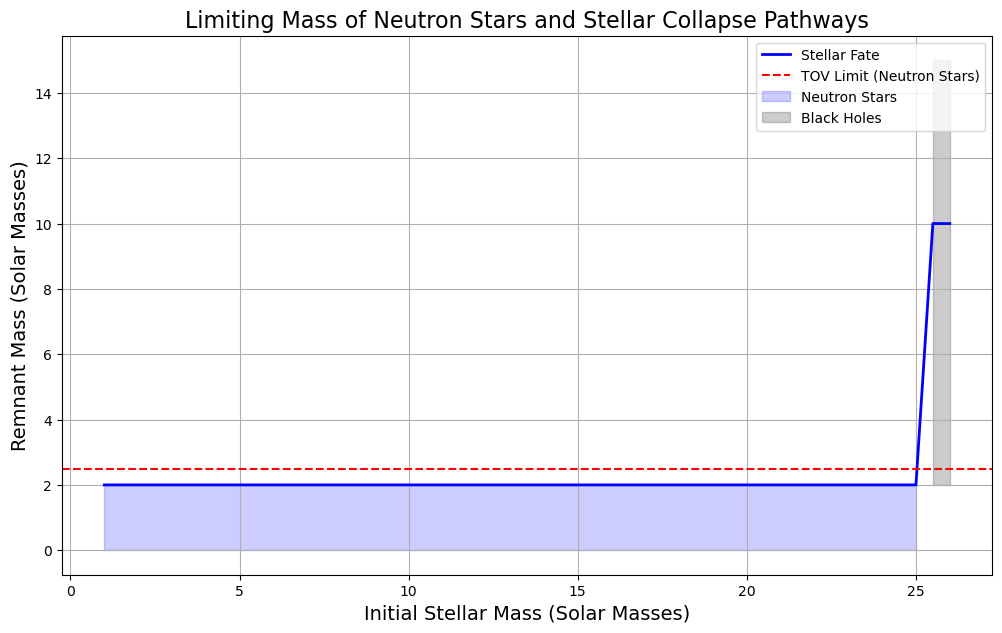

In [286]:
stellar_mass = np.linspace(1, 26, 51)  
fate = np.piecewise(stellar_mass,
                    [stellar_mass <= 25, stellar_mass > 25],
                    [lambda x: 2, lambda x: 10]) 
TOV = 2.5 * Mass1

plt.figure(figsize=(12, 7))
plt.plot(stellar_mass, fate, label='Stellar Fate', color='blue', lw=2)
plt.axhline(y=tov_limit, color='red', linestyle='--', label='TOV Limit (Neutron Stars)')
plt.title('Limiting Mass of Neutron Stars and Stellar Collapse Pathways', fontsize=16)
plt.xlabel('Initial Stellar Mass (Solar Masses)', fontsize=14)
plt.ylabel('Remnant Mass (Solar Masses)', fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.fill_between(stellar_mass, 0, 2, where=(stellar_mass <= 25), color='blue', alpha=0.2, label='Neutron Stars')
plt.fill_between(stellar_mass, 2, 15, where=(stellar_mass > 25), color='black', alpha=0.2, label='Black Holes')
plt.legend()
plt.show()

In [374]:
from scipy.optimize import curve_fit

x_data = np.linspace(1, 21, 51)
true_params_powerlaw = [10.0, -2.0]  

y_powerlaw = true_params_powerlaw[0] * x_data**true_params_powerlaw[1]
y_powerlaw_noise = 0.2 * np.random.normal(size=x_data.size)
y_powerlaw_observed = y_powerlaw + y_powerlaw_noise

def powerlaw_model(x, C, n):
    return C * x ** n

In [376]:
initial_guess_powerlaw = [1.0, -1.0]

params_powerlaw, cov_powerlaw = curve_fit(powerlaw_model, x_data, y_powerlaw_observed, p0=initial_guess_powerlaw)

errors_powerlaw = np.sqrt(np.diag(cov_powerlaw))
print("Power-Law Fit Results:")
for i, (param, error) in enumerate(zip(params_powerlaw, errors_powerlaw)):
    print(f"Parameter {i+1}: {param:.3f} +/- {error:.3f}")

Power-Law Fit Results:
Parameter 1: 9.669 +/- 0.206
Parameter 2: -1.972 +/- 0.059


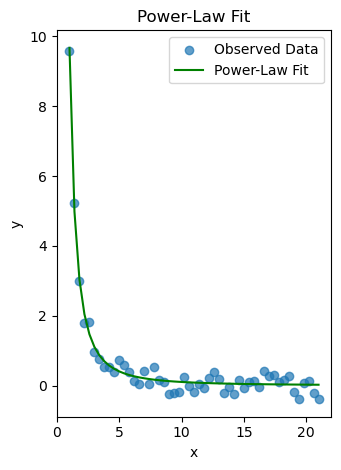

In [378]:
y_powerlaw_fitted = powerlaw_model(x_data, *params_powerlaw)

plt.subplot(1, 2, 2)
plt.scatter(x_data, y_powerlaw_observed, label="Observed Data", alpha=0.7)
plt.plot(x_data, y_powerlaw_fitted, label="Power-Law Fit", color="green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Power-Law Fit")
plt.legend()
plt.tight_layout()
plt.show()

In [380]:
residuals_powerlaw = y_powerlaw_observed - y_powerlaw_fitted
chi_squared_powerlaw = np.sum((residuals_powerlaw / 0.2) ** 2) 
reduced_chi_squared_powerlaw = chi_squared_powerlaw / (len(y_powerlaw_observed) - len(params_powerlaw))

print(f"Power-Law Reduced Chi-Squared: {reduced_chi_squared_powerlaw:.3f}")

Power-Law Reduced Chi-Squared: 1.195
